In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
import pandas as pd
import numpy as np
import os
from scipy.stats import spearmanr, pearsonr

os.chdir('../../../results/PlantCAD2_tasks/')

In [2]:
species  = ['arabidopsis_thaliana', 'Ptr', 'Osa', 'Zma']
ckpts    = ['c8192_pcv2-l24-d0768-checkpoints-lr-1e-4', 'c2048_pcv2-l24-d0768-checkpoints-lr-1e-4']

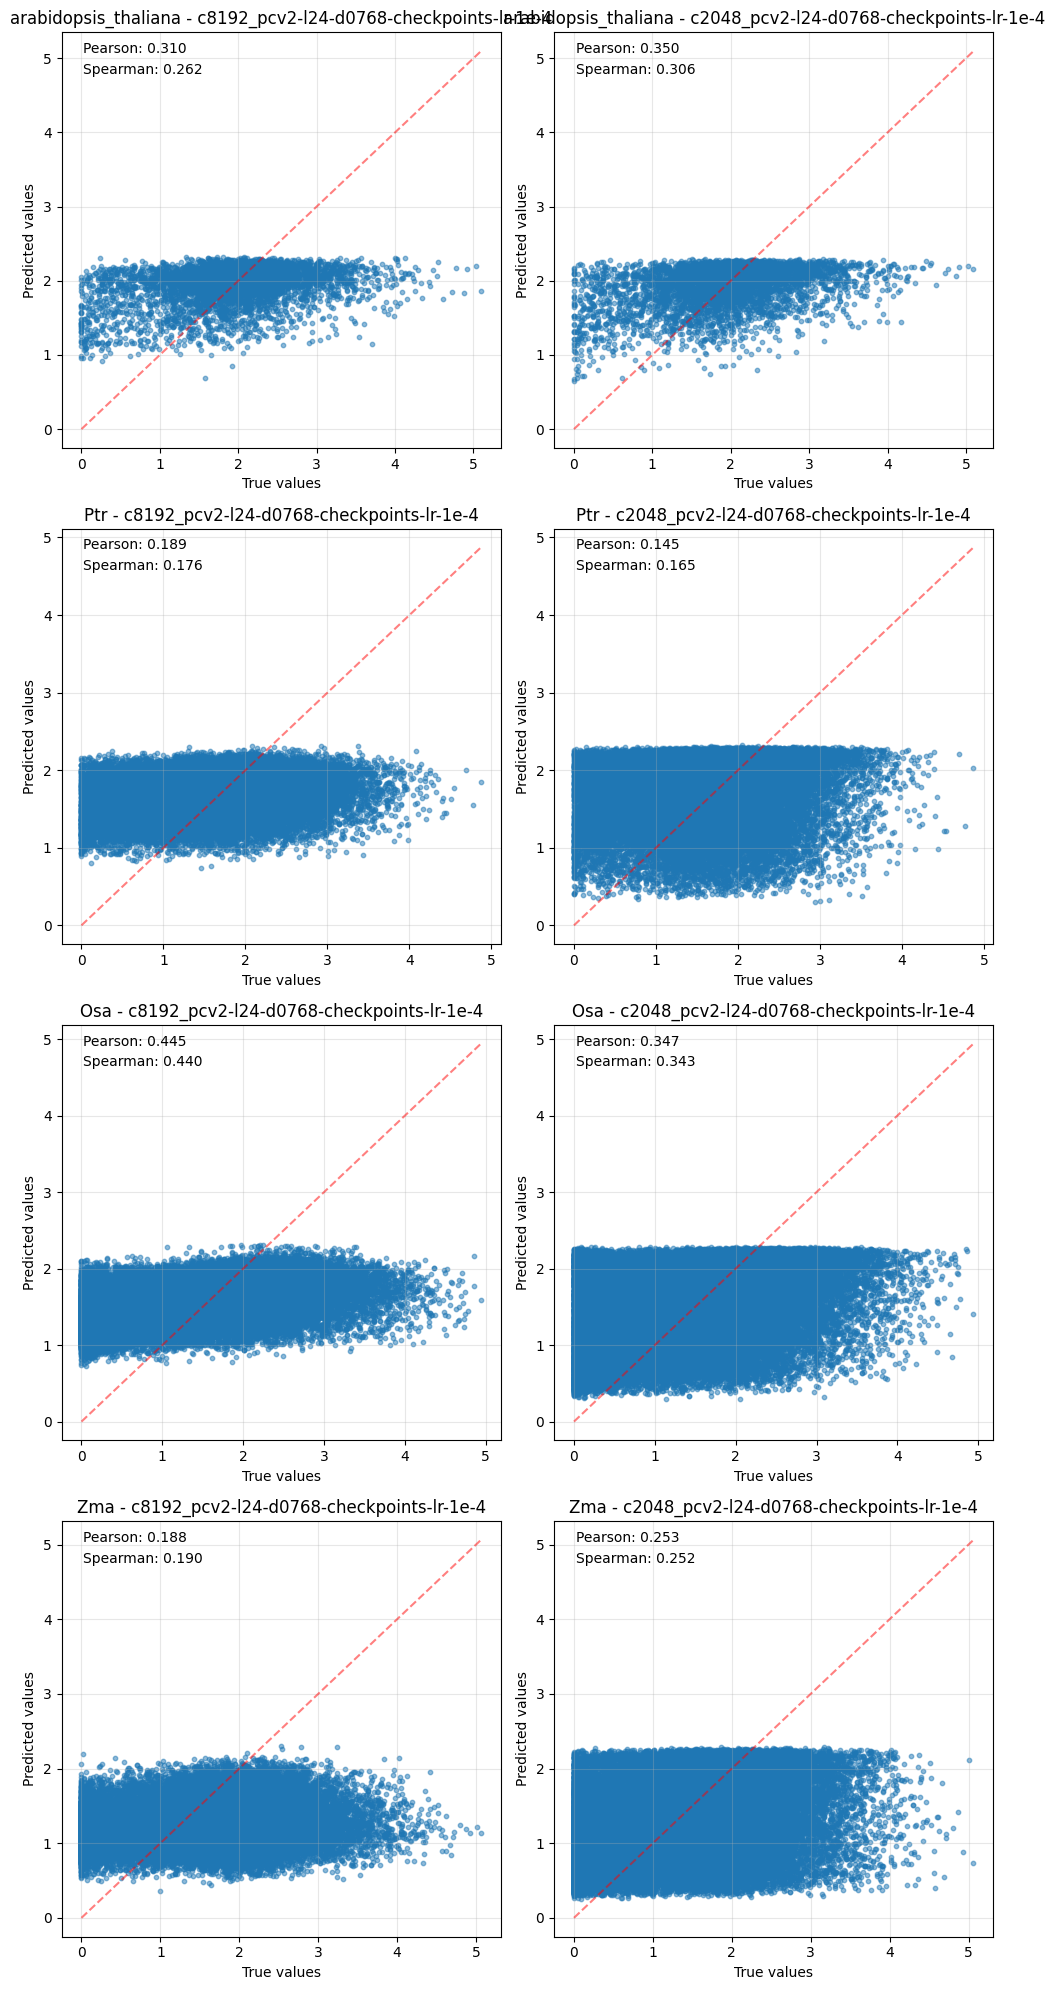

In [4]:
# Create figure
fig, axs = plt.subplots(len(species), len(ckpts), figsize=(len(ckpts)*5, len(species)*5))

# For storing correlation results
all_results = {}

for i, sp in enumerate(species):
    for k, ckpt in enumerate(ckpts):
        if sp == 'arabidopsis_thaliana':
            scores_path = (
                f'max_exp_angiosperm/models/{ckpt}/'
                f'valid_scores.tsv'
            )
            labels_path = f'max_exp_angiosperm/data/valid.tsv'
        else:
            scores_path = (
                f'max_exp_angiosperm/models/{ckpt}/'
                f'test_{sp}_scores.tsv'
            )
            labels_path = f'max_exp_angiosperm/data/test_{sp}.tsv'
            
        # Load data
        preds = pd.read_csv(scores_path, sep='\t')
        labels = pd.read_csv(labels_path, sep='\t')
        
        pred_values = preds['predicted_value']
        true_values = labels['Label']
        
        # Calculate correlations
        pearson_corr, p_value_pearson = pearsonr(pred_values, true_values)
        spearman_corr, p_value_spearman = spearmanr(pred_values, true_values)
        
        # Store results
        all_results[f"{sp}_{ckpt}"] = {
            "pearson": pearson_corr,
            "spearman": spearman_corr,
            "p_value_pearson": p_value_pearson,
            "p_value_spearman": p_value_spearman
        }
        
        # Get subplot axis
        if len(species) == 1:
            ax = axs[k] if len(ckpts) > 1 else axs
        elif len(ckpts) == 1:
            ax = axs[i]
        else:
            ax = axs[i, k]
        
        # Plot scatter
        ax.scatter(true_values, pred_values, alpha=0.5, s=10)
        
        # Add correlation values to plot
        ax.text(0.05, 0.95, f"Pearson: {pearson_corr:.3f}", transform=ax.transAxes)
        ax.text(0.05, 0.90, f"Spearman: {spearman_corr:.3f}", transform=ax.transAxes)
        
        # Add identity line
        min_val = min(min(true_values), min(pred_values))
        max_val = max(max(true_values), max(pred_values))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
        
        # Set titles and labels
        ax.set_title(f"{sp} - {ckpt}")
        ax.set_xlabel("True values")
        ax.set_ylabel("Predicted values")
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
# Create a summary dataframe of all correlations
summary = pd.DataFrame(all_results).T
summary.index.name = "Species_Checkpoint"
print(summary)

                                                     pearson  spearman  \
Species_Checkpoint                                                       
arabidopsis_thaliana_c8192_pcv2-l24-d0768-check...  0.310490  0.261917   
arabidopsis_thaliana_c2048_pcv2-l24-d0768-check...  0.349646  0.305915   
Ptr_c8192_pcv2-l24-d0768-checkpoints-lr-1e-4        0.188629  0.176423   
Ptr_c2048_pcv2-l24-d0768-checkpoints-lr-1e-4        0.144704  0.164729   
Osa_c8192_pcv2-l24-d0768-checkpoints-lr-1e-4        0.444899  0.439534   
Osa_c2048_pcv2-l24-d0768-checkpoints-lr-1e-4        0.347337  0.342622   
Zma_c8192_pcv2-l24-d0768-checkpoints-lr-1e-4        0.187525  0.189841   
Zma_c2048_pcv2-l24-d0768-checkpoints-lr-1e-4        0.252867  0.251529   

                                                    p_value_pearson  \
Species_Checkpoint                                                    
arabidopsis_thaliana_c8192_pcv2-l24-d0768-check...    4.059458e-124   
arabidopsis_thaliana_c2048_pcv2-l24-d0768-chec

In [6]:
summary

,pearson,spearman,p_value_pearson,p_value_spearman
Species_Checkpoint,,,,
arabidopsis_thaliana_c8192_pcv2-l24-d0768-checkpoints-lr-1e-4,0.310490,0.261917,4.059458e-124,1.358399e-87
arabidopsis_thaliana_c2048_pcv2-l24-d0768-checkpoints-lr-1e-4,0.349646,0.305915,4.445407e-159,2.303921e-120
Ptr_c8192_pcv2-l24-d0768-checkpoints-lr-1e-4,0.188629,0.176423,8.725567e-275,4.285338e-240
Ptr_c2048_pcv2-l24-d0768-checkpoints-lr-1e-4,0.144704,0.164729,2.257775e-161,3.624547e-209
Osa_c8192_pcv2-l24-d0768-checkpoints-lr-1e-4,0.444899,0.439534,0.000000e+00,0.000000e+00
Osa_c2048_pcv2-l24-d0768-checkpoints-lr-1e-4,0.347337,0.342622,0.000000e+00,0.000000e+00
Zma_c8192_pcv2-l24-d0768-checkpoints-lr-1e-4,0.187525,0.189841,5.324239e-306,0.000000e+00
Zma_c2048_pcv2-l24-d0768-checkpoints-lr-1e-4,0.252867,0.251529,0.000000e+00,0.000000e+00
